In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_stellarhalo
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import cosmo as co
import ludlow

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [18]:
test140 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_14.0.npz", mass_threshold=1e9, verbose=False)

test138 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.8.npz", mass_threshold=1e9, verbose=False)

test136 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.6.npz", mass_threshold=1e9, verbose=False)

test134 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.4.npz", mass_threshold=1e9, verbose=False)

test132 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.2.npz", mass_threshold=1e9, verbose=False)

test130 = jsm_stellarhalo.Tree_Reader(file="../../data/local_trees/evolved_trees/tree_13.0.npz", mass_threshold=1e9, verbose=False)

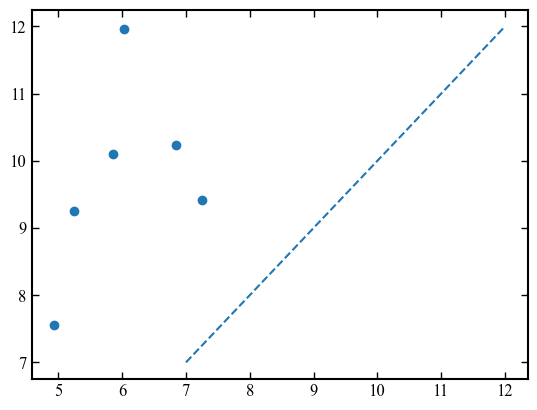

In [19]:
plt.scatter([test140.ludlow_c, test138.ludlow_c, test136.ludlow_c, test134.ludlow_c, test132.ludlow_c, test130.ludlow_c],
             [test140.concentration[0,0], test138.concentration[0,0], test136.concentration[0,0], test134.concentration[0,0], test132.concentration[0,0], test130.concentration[0,0]])
plt.plot(np.linspace(7, 12), np.linspace(7, 12), ls="--")

(1.2, 0.0)

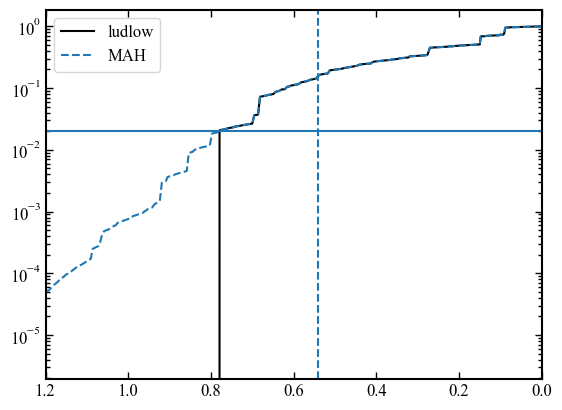

In [20]:
tree = test138

plt.plot(np.log10(1+cfg.zsample), tree.ludlow_CMH/tree.mass[0,0], label="ludlow", c="k")
plt.plot(np.log10(1+cfg.zsample), tree.mass[0]/tree.mass[0,0], label="MAH", ls="--")
plt.yscale("log")

plt.legend()
plt.axvline(np.log10(1+tree.ludlow_z2), ls="--")
plt.axhline(0.02)

plt.xlim(1.2, 0.0)

In [ ]:
zhao = jsm_ancillary.load_massspec_z0("../../data/zhao/N500/", regime="artificial", conctype=None)

In [ ]:
vdb = jsm_ancillary.load_massspec_z0("../../data/vdb/N500/", regime="artificial", conctype=None)

In [ ]:
ludlow = jsm_ancillary.load_massspec_z0("../../data/zhao/N500/", regime="artificial", conctype="ludlow")

In [16]:
measured = jsm_ancillary.load_massspec_z0("../../data/zhao/N500/", regime="artificial", conctype="measured")

In [17]:
satgen_zhao = jsm_simload.NormalizeData(zhao, dataset_title="zhao")

satgen_vdb = jsm_simload.NormalizeData(vdb, dataset_title="vdb")

satgen_ludlow = jsm_simload.NormalizeData(ludlow, dataset_title="ludlow")

satgen_measured = jsm_simload.NormalizeData(measured, dataset_title="measured")


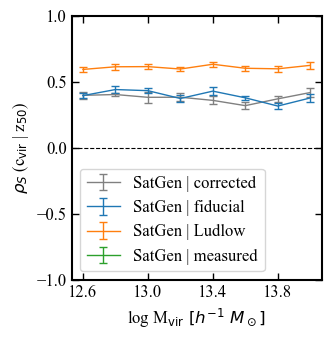

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(single_textwidth, single_textwidth), sharex=True, sharey=True)

datasets = [satgen_vdb, satgen_zhao, satgen_ludlow, satgen_measured]
colors = ["grey", "C0", "C1", "C2"]
labels = ["SatGen | corrected", "SatGen | fiducial", "SatGen | Ludlow", "SatGen | measured"]

for i,dataset in enumerate(datasets):
    axes.errorbar(dataset.logMvir_bincenters, dataset.rhocz_mat, yerr=dataset.rhocz_err_mat, color=colors[i], capsize=3, lw=1, label=labels[i])

axes.set_ylim(-1, 1)
axes.axhline(0, color="k", lw=0.8, ls="--")

axes.set_xlabel("log M$_{\\rm vir}\ [h^{-1}\ M_\odot]$")
axes.set_ylabel("$\\rho_S$ (c$_{\\rm vir}$ | z$_{50}$)")
axes.legend()
axes.set_xticks([12.6, 13.0, 13.4, 13.8])

plt.tight_layout()
# plt.savefig("../../figures/DF_rho.pdf", bbox_inches="tight")
plt.show()

In [20]:
satgen_measured.df

,logMvir,log1pz50,logc,Nsub,logNsub,fsub,logfsub,MMs,logMMs,z50,delta_log1pz50,delta_logc,delta_logNsub,delta_logMMs,delta_Nsub,delta_MMs,delta_logfsub,delta_fsub
1999,12.6,0.098967,NaN,0.0,NaN,0.000000,NaN,0.000000,NaN,0.255935,-0.197738,NaN,NaN,NaN,-1.121882,-0.051777,NaN,-0.058406
1341,12.6,0.180972,NaN,0.0,NaN,0.000000,NaN,0.000000,NaN,0.516951,-0.115734,NaN,NaN,NaN,-1.121882,-0.051777,NaN,-0.058406
1340,12.6,0.216833,NaN,0.0,NaN,0.000000,NaN,0.000000,NaN,0.647528,-0.079872,NaN,NaN,NaN,-1.121882,-0.051777,NaN,-0.058406
1339,12.6,0.302382,1.091796,1.0,0.000000,0.020078,-1.697288,0.020078,-1.697288,1.006234,0.005676,-12.508204,-0.049947,-0.411424,-0.121882,-0.031699,-0.463748,-0.038329
1338,12.6,0.305693,NaN,0.0,NaN,0.000000,NaN,0.000000,NaN,1.021588,0.008987,NaN,NaN,NaN,-1.121882,-0.051777,NaN,-0.058406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4661,14.0,0.255878,0.969427,17.0,1.230449,0.115334,-0.938044,0.093831,-1.027653,0.802511,0.037737,-14.030573,-0.047534,0.446319,-1.966329,0.060255,0.069143,0.016975
4660,14.0,0.203701,NaN,20.0,1.301030,0.205816,-0.686520,0.115135,-0.938791,0.598457,-0.014440,NaN,0.023047,0.535181,1.033671,0.081559,0.320666,0.107457
4659,14.0,0.103226,NaN,22.0,1.342423,0.163414,-0.786710,0.051942,-1.284481,0.268312,-0.114915,NaN,0.064439,0.189492,3.033671,0.018366,0.220477,0.065056
4672,14.0,0.166396,NaN,23.0,1.361728,0.115806,-0.936269,0.029214,-1.534405,0.466884,-0.051745,NaN,0.083745,-0.060433,4.033671,-0.004362,0.070918,0.017447
